### Pitch Control analysis in the WC2022 using pff data

FERNANDEZ BUT ALSO THE OTHER ARTICLE THEY DO THE SAME FOR PITCH VALUE. MENTION BOTH AND TAKE BOTH AS INSPIRATION

In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from kloppy import pff
from databallpy import get_game_from_kloppy
from Utils.config import BASE_PATH, LOG_PATH
from Utils.loading import load_files, load_game_from_pff
from Utils.helpers import clean_tracking_data, bz2_to_parquet
from matplotlib.colors import LinearSegmentedColormap
from databallpy.visualize import plot_soccer_pitch, plot_tracking_data
import time

In [ ]:
# This has been done in the previous project. Data is already cleaned
clean_tracking_data(BASE_PATH)
bz2_to_parquet(BASE_PATH)

Loading data

In [3]:
for game_id in dict_events.keys():
    events_df = dict_events[game_id]
    tracking_df = dict_tracking[game_id]

# Create a game object
game = load_game_from_pff(BASE_PATH, game_id)

c:\Users\g4a4b\anaconda3\envs\counterpress\lib\site-packages\databallpy\schemas\tracking_data.py:64: DataBallPyWarning: The middle point of the pitch should be (0, 0), now the kick-off is at (-1.67, 6.9). Either the recording has started too late or the ball_status is not set to 'alive' in the beginning. Please check and  change the tracking data if desired.
 NOTE: The quality of the synchronisation of the tracking and event data might be affected.
  warnings.warn(message=message, category=DataBallPyWarning)
c:\Users\g4a4b\anaconda3\envs\counterpress\lib\site-packages\databallpy\schemas\tracking_data.py:64: DataBallPyWarning: The middle point of the pitch should be (0, 0), now the kick-off is at (-1.67, 6.9). Either the recording has started too late or the ball_status is not set to 'alive' in the beginning. Please check and  change the tracking data if desired.
 NOTE: The quality of the synchronisation of the tracking and event data might be affected.
  warnings.warn(message=message, 

Loaded tracking data for game 10502


#### 1. Pitch control implementation with databallpy
check that it works

3916
(1, 68, 105)


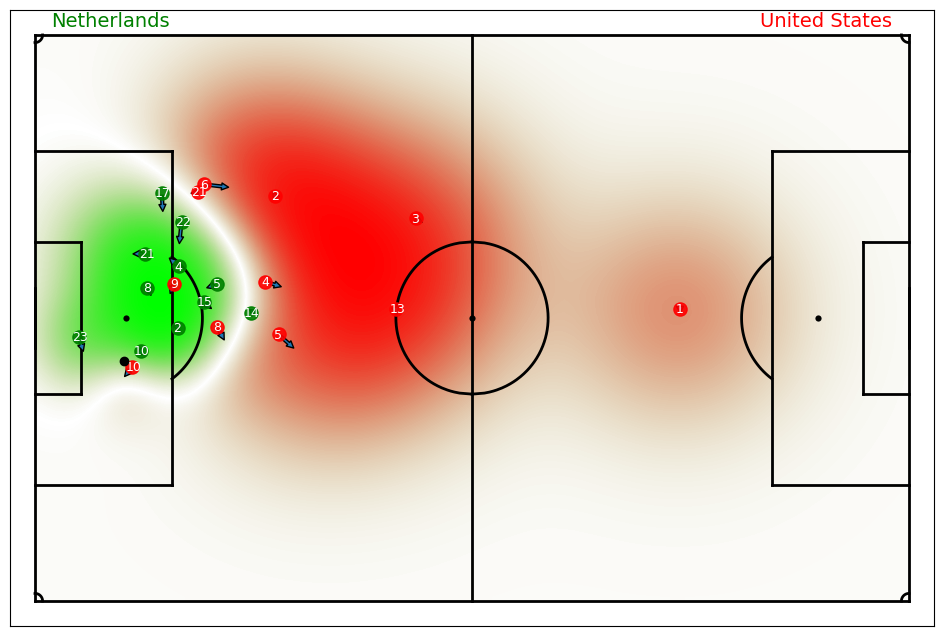

In [16]:
# Get a shot in events_df
shot_event = events_df[events_df['possessionEvents.possessionEventType'] == 'SH'].iloc[0]
# Find the corresponding shot in tracking_df
shot_tracking = tracking_df[tracking_df["possession_event_id"] == shot_event["possessionEventId"]].copy()

def get_frame(tracking_event_df):
    tracking_event_df["possession_start_frame"] = tracking_event_df["possession_event"].apply(
        lambda x: x.get("start_frame") if isinstance(x, dict) else None)
    return tracking_event_df

shot_tracking = get_frame(shot_tracking)
# Get the start frame of the possession event for this pass
possession_start_frame = shot_tracking.get("possession_start_frame")
# get the index of the frame in game_tracking_frame
idx_frame = game.tracking_data[game.tracking_data["frame"] == possession_start_frame.values[0]].index[0]
print(idx_frame)
pitch_control = game.tracking_data.get_pitch_control(game.pitch_dimensions, 105, 68, idx_frame,idx_frame)
print(pitch_control.shape)
cmap_red_green = LinearSegmentedColormap.from_list("reds", [(0, 1, 0, 1), (0.5, 0.5, 0, 0), (1, 0, 0, 1)])

fig, ax = plot_soccer_pitch(field_dimen=game.pitch_dimensions, pitch_color="white")
fig, ax = plot_tracking_data(game, idx_frame, team_colors=["green", "red"], ax=ax, fig=fig, add_velocities=True, heatmap_overlay=pitch_control[0], overlay_cmap=cmap_red_green)

plt.show()

#### 2. Pitch value model based on the paper

In [3]:
# First, identify defensive situations in event data
def identify_defensive_situations(tracking_df):
    tracking_df["team_in_possession"] = tracking_df["game_event"].apply(
        lambda x: x.get("team_name") if isinstance(x, dict) else None
    )
    tracking_df["home_team_in_possession"] = tracking_df["game_event"].apply(
        lambda x: x.get("home_team") if isinstance(x, dict) else None
    )

    tracking_team_not_null = tracking_df[tracking_df["team_in_possession"].notnull()].copy()
    tracking_team_not_null["time_bin_3s"] = (tracking_team_not_null["periodGameClockTime"] // 3).astype(int)
    tracking_rows = (
        tracking_team_not_null.sort_values(["period", "periodGameClockTime"])
        .groupby(["period", "time_bin_3s"])
        .first()
        .reset_index()
    )

    def valid_ball(x):
        if not isinstance(x, dict):
            return False
        
        x_val = x.get("x")
        y_val = x.get("y")
        
        return (
            x_val is not None and y_val is not None and
            not np.isnan(x_val) and not np.isnan(y_val)
        )

    def valid_players(arr):
        if not isinstance(arr, np.ndarray) or arr.size == 0:
            return False

        for player in arr:
            if not isinstance(player, dict):
                return False
            
            x = player.get("x")
            y = player.get("y")

            try:
                if not (np.isfinite(x) and np.isfinite(y)):
                    return False
            except:
                return False

        return True

    tracking_rows = tracking_rows[
    (tracking_rows["ballsSmoothed"].apply(valid_ball)) &
    (tracking_rows["homePlayersSmoothed"].apply(valid_players)) &
    (tracking_rows["awayPlayersSmoothed"].apply(valid_players))
    ].copy()

    return tracking_rows

# Get the pitch control for each of these rows
def get_pitch_control_for_row(row, game):
    idx_frame = game.tracking_data[game.tracking_data["frame"] == row["frameNum"]].index[0]
    try:
        pitch_control = game.tracking_data.get_pitch_control(game.pitch_dimensions, 105, 68, idx_frame, idx_frame)
        return pitch_control
    except Exception as e:
        return None

def downsample_pitch_control(pc, n_x=21, n_y=15):
    pc = pc[0]  # remove time dimension → (105, 68)

    x_bins = np.array_split(pc, n_x, axis=0)
    pc_down = [np.array_split(xb, n_y, axis=1) for xb in x_bins]

    # Average each cell
    pc_down = np.array([[cell.mean() for cell in row] for row in pc_down])

    return pc_down  # shape (21, 15)

def get_grid_centers(n_x=21, n_y=15, pitch_length=105, pitch_width=68):
    x_edges = np.linspace(-pitch_length/2, pitch_length/2, n_x + 1)
    y_edges = np.linspace(-pitch_width/2, pitch_width/2, n_y + 1)

    # centers = midpoint of edges
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2

    return x_centers, y_centers

def creation_pv_dataset(tracking_df, game):
    x_centers, y_centers = get_grid_centers(21, 15, game.pitch_dimensions[0], game.pitch_dimensions[1])
    X, Y = np.meshgrid(x_centers, y_centers, indexing="ij")  # shapes (21,15)
    print(X.shape, Y.shape)

    tracking_rows = identify_defensive_situations(tracking_df)
    data_rows = []
    # Loop over frames
    for idx, row in tracking_rows.iterrows():
        pitch_control = get_pitch_control_for_row(row, game)
        
        if pitch_control is None:
            continue  # skip frames without pitch control

        pc_down = downsample_pitch_control(pitch_control, 21,15)  # shape (21,15)
        ball_x, ball_y = row["ballsSmoothed"]["x"], row["ballsSmoothed"]["y"]

        if not row["home_team_in_possession"]:
            pc_down = 1 - pc_down  # flip values if home team is not in possession

        # Flatten arrays to get one row per cell
        X_flat = X.ravel()
        Y_flat = Y.ravel()
        PC_flat = pc_down.ravel()
        BALL_X = np.full_like(X_flat, ball_x)
        BALL_Y = np.full_like(Y_flat, ball_y)

        game_id = row["gameRefId"]
        frameNum = row["frameNum"]

        # Combine into a DataFrame
        df_frame = pd.DataFrame({
            "game_id": game_id,
            "frameNum": frameNum,
            "ball_x": BALL_X,
            "ball_y": BALL_Y,
            "cell_x": np.round(X_flat, 3),
            "cell_y": np.round(Y_flat, 3),
            "defending_value": np.round(PC_flat, 3)
        })

        data_rows.append(df_frame)

    # Concatenate all frames
    dataset = pd.concat(data_rows, ignore_index=True)
    print("Total frames in tracking data:", len(tracking_rows["frameNum"].unique()))
    print("Ratio of valid frames:", len(dataset["frameNum"].unique()) / len(tracking_rows["frameNum"].unique()) * 100, "%")
    print("Average number of rows per frame:", len(dataset) / len(dataset["frameNum"].unique()))
    return dataset

# Now this function should be applied to all the games

Whole Pipeline. You can use it as inspiration

In [4]:
game_ids = [gid.split(".")[0] for gid in os.listdir(os.path.join(BASE_PATH, "eventdata"))]

total_frames = 0
total_rows = 0
for game_id in game_ids[1:]:
    # Loading data for the game
    print(f"Processing game {game_id}...")
    event_df, tracking_df = load_files(BASE_PATH, game_id)
    game = load_game_from_pff(BASE_PATH, game_id)
    print("Data loaded successfully. Creating dataset...")
    dataset = creation_pv_dataset(tracking_df, game)
    print("Dataset created.")
    total_frames += len(dataset["frameNum"].unique())
    total_rows += len(dataset)
    os.makedirs(os.path.join(BASE_PATH, "datasets_pitch_value"), exist_ok=True)
    dataset.to_csv(os.path.join(BASE_PATH, "datasets_pitch_value", f"dataset_{game_id}.csv"), index=False)
    print(f"Dataset for game {game_id} saved.")
    print("-" * 50)
    time.sleep(10)

print(f"Total frames processed: {total_frames}")
print(f"Total rows in all datasets: {total_rows}")

Processing game 10503...
--------------------------------------------------
Loaded 10503: 2492 events
Loaded 10503: 178797 rows


SchemaError: Column 'ball_x' failed element-wise validator number 0: greater_than_or_equal_to(-62.5) failure cases: -62.71999999999999, -63.020000000000024, -63.32, -63.620000000000005

In [12]:
tracking_df["ball_x"] = tracking_df["ballsSmoothed"].apply(lambda b: b["x"] if isinstance(b, dict) else None)
tracking_df["ball_y"] = tracking_df["ballsSmoothed"].apply(lambda b: b["y"] if isinstance(b, dict) else None)
print(tracking_df["ball_x"].min(), tracking_df["ball_x"].max())
print(tracking_df["ball_y"].min(), tracking_df["ball_y"].max())

-56.25 63.62
-36.21 36.03
